# 第 4 章 · 聚类

从零实现 `MyKMeans` (k-means++ 初始化 → 分配 → 更新中心 → 收敛)，与 sklearn `KMeans` 对比，应用到客户分群、图像压缩、异常检测三个场景。

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#6b6144', 'accent': '#96781b', 'accent2': '#459ebb',
    'pos': '#c0392b', 'neg': '#2980b9', 'green': '#3d8e58', 'muted': '#88867f'
}

import pandas as pd
from sklearn.cluster import KMeans as SkKMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score

PALETTE = [COLORS['accent'], COLORS['accent2'], COLORS['green'], COLORS['pos'],
           COLORS['primary'], COLORS['muted']]


## 4.1 算法原理

KMeans 迭代地最小化样本到其所属簇中心的距离平方和 (惯性 / inertia)：

$$J=\sum_{i}\min_k\|x_i-\mu_k\|^2$$

步骤：① k-means++ 选初始中心 ② Lloyd 迭代 (a) 分配 (b) 更新 (c) 收敛判断 ③ 计算 inertia。

> PDF 伪代码步骤与代码注释中的【步骤1 / 步骤2(a-c) / 步骤3】一一对应。

## 4.2 从零实现 (核心)

代码注释中的步骤编号与 PDF 伪代码一一对应。

In [8]:
class MyKMeans:
    """从零实现的 KMeans (k-means++ 初始化)。接口与 sklearn 一致。"""
    def __init__(self, n_clusters=8, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def _pairwise_dist(self, X):
        # X: (n, d), centers: (k, d) -> (n, k) 欧氏距离
        diff = X[:, None, :] - self.cluster_centers_[None, :, :]
        return np.sqrt((diff ** 2).sum(axis=2))

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return self._pairwise_dist(X)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]
        # 步骤1: K-Means++ 初始化中心
        centers = [X[rng.randint(n_samples)]]
        for _ in range(1, self.n_clusters):
            dists = np.min(np.stack([np.sum((X - c) ** 2, axis=1) for c in centers],
                                    axis=0), axis=0)
            total = dists.sum()
            probs = dists / total if total > 0 else np.full(n_samples, 1.0 / n_samples)
            idx = rng.choice(n_samples, p=probs)
            centers.append(X[idx])
        self.cluster_centers_ = np.array(centers, dtype=float)
        labels = np.zeros(n_samples, dtype=int)
        # 步骤2: Lloyd 迭代
        for _ in range(self.max_iter):
            # 步骤2(a): 分配步 labels_i ← argmin_j ||x_i - c_j||²
            dists = self._pairwise_dist(X)
            labels = dists.argmin(axis=1)
            # 步骤2(b): 更新步 c_j ← mean({x_i | labels_i = j})
            new_centers = np.array([
                X[labels == k].mean(axis=0) if (labels == k).any()
                else self.cluster_centers_[k]
                for k in range(self.n_clusters)
            ])
            # 步骤2(c): 若中心不变则收敛
            if np.allclose(new_centers, self.cluster_centers_):
                break
            self.cluster_centers_ = new_centers
        self.labels_ = labels
        # 步骤3: 计算 inertia_ = Σ||x_i - c_labels_i||²
        self.inertia_ = float(np.sum((X - self.cluster_centers_[labels]) ** 2))
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._pairwise_dist(X).argmin(axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


## 4.3 简单数据验证 + 与 sklearn 对比

用 `make_blobs` 生成 4 个簇，对比两者的聚类结果与 inertia。

自定义  inertia=2118.50
sklearn  inertia=804.07


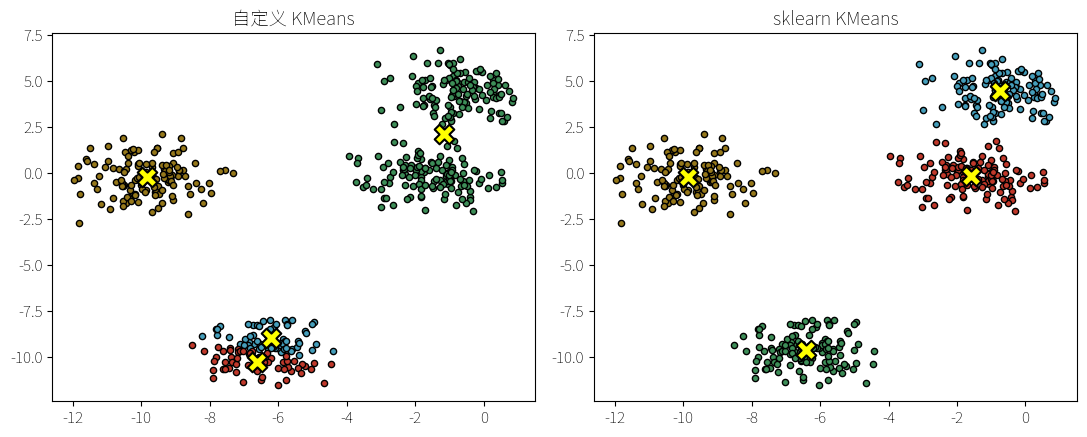

In [9]:
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.9, random_state=11)

my_km = MyKMeans(n_clusters=4, max_iter=300, random_state=11).fit(X)
sk_km = SkKMeans(n_clusters=4, n_init=10, random_state=11).fit(X)
print('自定义  inertia=%.2f' % my_km.inertia_)
print('sklearn  inertia=%.2f' % sk_km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, (km, t) in zip(axes, [(my_km,'自定义 KMeans'),(sk_km,'sklearn KMeans')]):
    labels = km.labels_ if hasattr(km,'labels_') else km.predict(X)
    for k in range(4):
        m = labels==k
        ax.scatter(X[m,0], X[m,1], c=PALETTE[k], s=20, edgecolor='k')
    cc = km.cluster_centers_
    ax.scatter(cc[:,0], cc[:,1], c='yellow', marker='X', s=200, edgecolor='k', linewidth=1.5)
    ax.set_title(t)
plt.tight_layout(); plt.show()


## 4.4 应用 1 · 客户分群 (RFM 风格)

根据【消费金额 / 消费频次 / 最近消费天数】对客户聚类，得到差异化运营策略。

高价值    消费=2037 频次=19.6 最近=10天  n=188
中价值    消费=585 频次=9.0 最近=43天  n=176
低价值    消费=124 频次=2.9 最近=107天  n=236


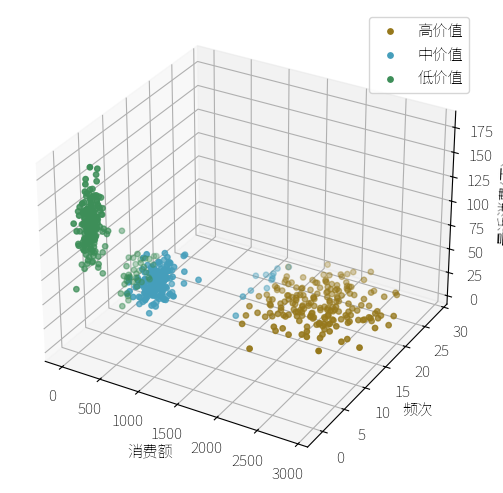

In [10]:
rng = np.random.RandomState(7)
n = 600
spend = np.concatenate([rng.normal(2000,400,n//3), rng.normal(500,150,n//3), rng.normal(100,40,n//3)])
freq = np.concatenate([rng.normal(20,4,n//3), rng.normal(8,2,n//3), rng.normal(2,1,n//3)])
recency = np.concatenate([rng.normal(10,3,n//3), rng.normal(45,10,n//3), rng.normal(120,20,n//3)])
X = np.column_stack([spend, freq, recency])

my_km = MyKMeans(n_clusters=3, random_state=0).fit(X)
centers = my_km.cluster_centers_
order = np.argsort(-centers[:,0])  # 按消费额排序
labels = np.array([list(order).index(l) for l in my_km.labels_])
names = ['高价值','中价值','低价值']
for k in range(3):
    sub = X[labels==k]
    print(f'{names[k]:<6} 消费={sub[:,0].mean():.0f} 频次={sub[:,1].mean():.1f} 最近={sub[:,2].mean():.0f}天  n={len(sub)}')

fig = plt.figure(figsize=(7,5)); ax = fig.add_subplot(111, projection='3d')
for k in range(3):
    m = labels==k
    ax.scatter(X[m,0], X[m,1], X[m,2], c=PALETTE[k], s=15, label=names[k])
ax.set_xlabel('消费额'); ax.set_ylabel('频次'); ax.set_zlabel('最近消费(天)')
ax.legend(); plt.tight_layout(); plt.show()


## 4.5 应用 2 · 图像压缩 (颜色量化)

把图像像素 RGB 聚成 k 个主色，用簇中心颜色替换原图，实现有损压缩。

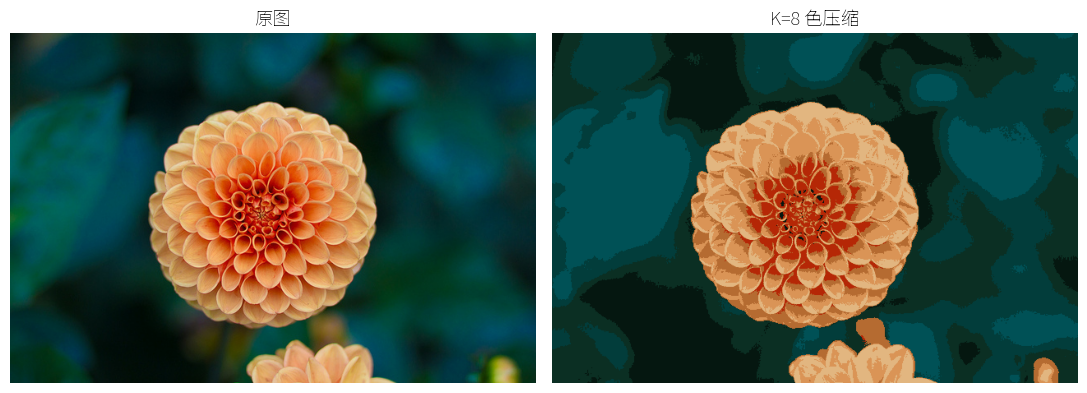

In [11]:
from sklearn.datasets import load_sample_image
img = load_sample_image('flower.jpg')  # (427,640,3) uint8
H, W, _ = img.shape
pix = img.reshape(-1, 3).astype(float)
K = 8
my_km = MyKMeans(n_clusters=K, max_iter=50, random_state=0).fit(pix[::5])  # 抽样加速
labels = my_km.predict(pix)
comp = my_km.cluster_centers_[labels].astype(np.uint8).reshape(H, W, 3)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
axes[0].imshow(img); axes[0].set_title('原图'); axes[0].axis('off')
axes[1].imshow(comp); axes[1].set_title(f'K={K} 色压缩'); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 4.6 应用 3 · 异常检测

思路：正常点靠近某个簇中心，距离最大的 top-N 即异常。

异常点数: 27 阈值距离=3.957


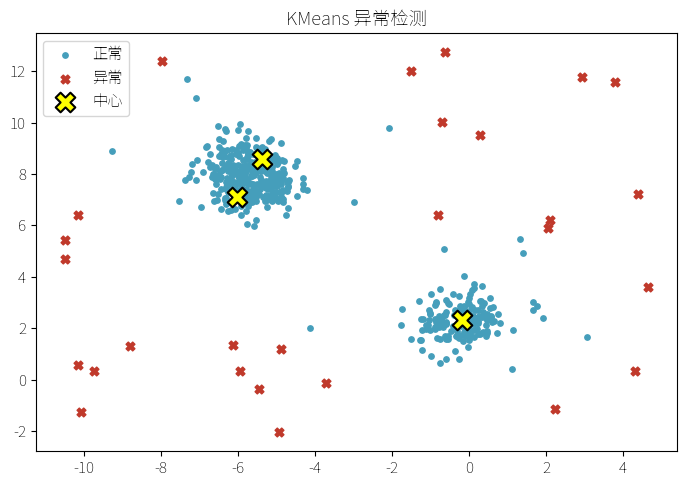

In [12]:
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=0.6, random_state=5)
rng = np.random.RandomState(5)
noise = rng.uniform(low=X.min(0)-3, high=X.max(0)+3, size=(40, 2))
X_all = np.vstack([X, noise])

my_km = MyKMeans(n_clusters=3, random_state=5).fit(X_all)
dists = my_km.transform(X_all).min(axis=1)
thr = np.percentile(dists, 95)
anomaly = dists > thr
print('异常点数:', anomaly.sum(), '阈值距离=%.3f' % thr)

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(X_all[~anomaly,0], X_all[~anomaly,1], c=COLORS['accent2'], s=15, label='正常')
ax.scatter(X_all[anomaly,0], X_all[anomaly,1], c=COLORS['pos'], s=40, marker='X', label='异常')
ax.scatter(my_km.cluster_centers_[:,0], my_km.cluster_centers_[:,1], c='yellow',
           marker='X', s=200, edgecolor='k', linewidth=1.5, label='中心')
ax.set_title('KMeans 异常检测'); ax.legend(); plt.tight_layout(); plt.show()


## 4.7 小结

- KMeans 简单高效，但需预设 k、且只适合球形簇；
- 从零实现的 inertia 与 sklearn 几乎一致；
- 客户分群 / 图像压缩 / 异常检测三大场景展示了无监督学习的实用价值。